# Project: Investigate a Dataset - Dataset-No-show appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction


### Dataset Description 

The analysis focuses on the 'Medical Appointment No Shows' dataset available on Kaggle, which compiles information from approximately 110.527 medical appointments within Brazil's public health system, known as SUS (Sistema Único de Saúde). 

Dataset Description
The dataset includes 14 different features, providing a broad spectrum of information ranging from personal patient details to appointment specifics. Here is an overview of each feature:

<ul>
    <li><strong>PatientId:</strong> Identification of a patient.</li>
    <li><strong>AppointmentID:</strong> Identification of each appointment.</li>
    <li><strong>Gender:</strong> Male or Female; it's noted that females generally tend to be more proactive in maintaining their health.</li>
    <li><strong>ScheduledDay:</strong> The date on which the appointment was scheduled, indicating when the appointment was made.</li>
    <li><strong>AppointmentDay:</strong> The actual date of the appointment.</li>
    <li><strong>Age:</strong> The patient's age.</li>
    <li><strong>Neighbourhood:</strong> The location where the appointment takes place.</li>
    <li><strong>Scholarship:</strong> Indicates whether the patient is a beneficiary of the Bolsa Família program, a Brazilian social welfare program.</li>
    <li><strong>Hipertension:</strong> Indicates if the patient has hypertension (True or False).</li>
    <li><strong>Diabetes:</strong> Indicates if the patient has diabetes (True or False).</li>
    <li><strong>Alcoholism:</strong> Indicates if the patient has alcoholism issues (True or False).</li>
    <li><strong>Handcap:</strong> The degree of handicap of the patient (True or False).</li>
    <li><strong>SMS_received:</strong> Number of SMS messages sent to the patient as reminders.</li>
    <li><strong>No-show:</strong> Indicates if the patient missed the appointment (Yes or No).</li>
</ul>

### Question(s) for Analysis

1) What is the relationship between health conditions and patient no-shows?
2) Does the time between scheduling and the appointment date affect no-show probabilities?

 import pandas, numpy, seaborn and matplotlib.

In [47]:
# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<a id='wrangling'></a>
## Data Wrangling
 I will load the data, then trim and clean my dataset for analysis.
### General Properties

read the csv file and print the first 5 rows

In [48]:
df = pd.read_csv('Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No



### Data Cleaning

the type of each element and null values 

In [49]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


(110527, 14)

check if there is a duplicated values

In [50]:
df.duplicated().sum()

0

there is no null or duplicated data

In [51]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


unique values for Gender and no show to make sure there is no mislead value

In [52]:
print(df['Gender'].unique())
print(df['No-show'].unique())

['F' 'M']
['No' 'Yes']


Fix columns names

In [53]:
df.rename(columns={"Handcap": "Handicap"}, inplace=True)
df.rename(columns={"Hipertension": "Hypertension"}, inplace=True)
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show'],
      dtype='object')

make sure there is no negative values

In [54]:
df.replace({'Age': {-1: 0}}, inplace = True)
df.Age.describe()

count    110527.000000
mean         37.088883
std          23.110190
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [55]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


change the type for the date columns from object to date

In [56]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

Calculate the difference between the scheduled day and the appointment day to create a new column in the DataFrame. This

In [57]:
df['DayBetween'] = df.AppointmentDay - df.ScheduledDay

# convert derived datetime to int
df['DayBetween'] = df['DayBetween'].dt.days


In [58]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,DayBetween
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,-1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,-1
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,-1
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,-1
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,-1


In [59]:
df.DayBetween.describe()

count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: DayBetween, dtype: float64

change all negative values to 0

In [60]:
df.loc[df['DayBetween'] < 0, 'DayBetween'] = 0
df.DayBetween.describe()

count    110527.000000
mean          9.532739
std          15.027729
min           0.000000
25%           0.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: DayBetween, dtype: float64

In [61]:
df.DayBetween.unique()

array([  0,   1,   2,   3,   8,  28,   9,  22,  10,  17,  16,  13,  27,
        23,  20,  14,  15,  21,  42,  29,  30,  41,  31,  55,  44,  45,
        38,  36,  37,  43,  49,  59,  51,  52,  64,  66,  90,  65,  83,
        77,  86, 114, 108,  62,  69,  71,  56,  57,  50,  58,  40,  48,
        72,  63,  19,  32,  33,   5,  34,  35,  11,  12,  39,  46,   7,
         4,   6,  24,  25,  47,  26,  18,  60,  54,  61, 175,  53,  76,
        68,  82,  75,  88,  80, 102,  78,  67,  74,  84, 111,  79,  85,
        97,  93, 141, 154, 161, 168, 103, 132, 124,  95,  87,  89, 150,
       125, 126, 110, 118,  73,  70,  81, 107, 109, 101, 121, 100, 104,
        91,  96,  92, 106,  94, 138, 131, 178, 116, 145, 122])

drop the columns i don't need  

In [62]:
df.drop(columns=['Neighbourhood', 'ScheduledDay', 'AppointmentDay'], inplace=True)
print(df.columns)

Index(['PatientId', 'AppointmentID', 'Gender', 'Age', 'Scholarship',
       'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received',
       'No-show', 'DayBetween'],
      dtype='object')


Segment values into bins
The maximum value is 178 and minimum is 0 values are so big that we have to segment them into bins

In [63]:
bins = pd.IntervalIndex.from_tuples([(0, 1), (1, 5), (5, 10), (10, 200)])
labels=["Now", "LOW-Days", "Medium-Days", "High-Days"]
df['DayBetween'] = pd.cut(df['DayBetween'], bins=bins, labels=labels)
print(df['DayBetween'].value_counts())

(10, 200]    33459
(1, 5]       15341
(5, 10]      11221
(0, 1]        6725
Name: DayBetween, dtype: int64


Convert 'No-show' to numeric-format so i can calculate the mean

In [64]:
df.rename(columns={"No-show": "Show"}, inplace=True)
df.replace({'Show': {'No': 1, 'Yes': 0}}, inplace = True)
df.head()

,PatientId,AppointmentID,Gender,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,Show,DayBetween
0,2.987250e+13,5642903,F,62,0,1,0,0,0,0,1,NaN
1,5.589978e+14,5642503,M,56,0,0,0,0,0,0,1,NaN
2,4.262962e+12,5642549,F,62,0,0,0,0,0,0,1,NaN
3,8.679512e+11,5642828,F,8,0,0,0,0,0,0,1,NaN
4,8.841186e+12,5642494,F,56,0,1,1,0,0,0,1,NaN


In [65]:
print(df.columns)

Index(['PatientId', 'AppointmentID', 'Gender', 'Age', 'Scholarship',
       'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received',
       'Show', 'DayBetween'],
      dtype='object')


<a id='eda'></a>
## Exploratory Data Analysis

lets take a look at the no show percent before start answering

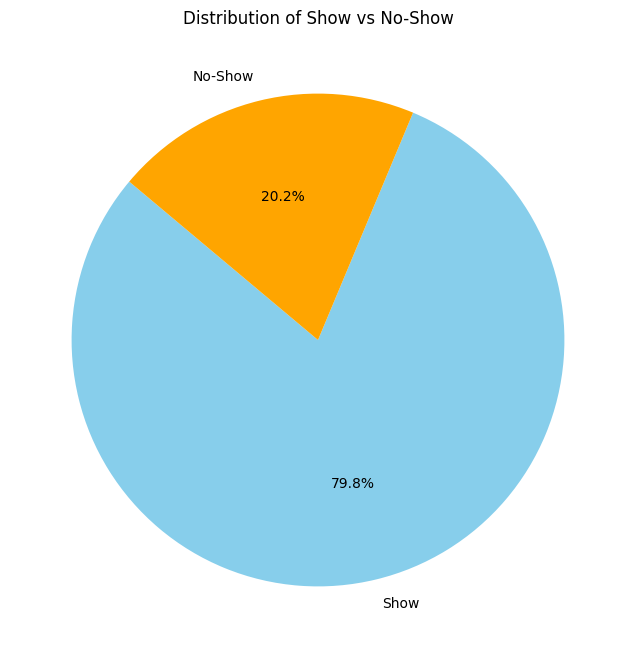

In [66]:
show_counts = df['Show'].value_counts();
plt.figure(figsize=(8, 8));
plt.pie(show_counts, labels=['Show', 'No-Show'], autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange']);
plt.title('Distribution of Show vs No-Show');
plt.show();

### Research Question 1 time between scheduling and the appointment date affect no-show probabilities

Groupby 'DayBetween' to check if affects No-show

In [67]:
# Use this, and more code cells, to explore your data. Don't forget to add
#   Markdown cells to document your observations and findings.
DB = df.groupby('DayBetween').mean(numeric_only=True)['Show']
DB.head()

DayBetween
(0, 1]       0.761784
(1, 5]       0.755687
(5, 10]      0.717405
(10, 200]    0.674587
Name: Show, dtype: float64

make a function for the plot so i can call it in the two questions 

In [39]:
def draw_plot(locations, heights, labels, chartTitle, chartXlabel, chartYlabel, bar_color='skyblue'):
    plt.bar(locations, heights, tick_label=labels, color=bar_color)
    plt.title(chartTitle)
    plt.xlabel(chartXlabel)
    plt.ylabel(chartYlabel);

This bar plot examines the probability of patients showing up to their appointments across different 'Day Between' categories: 'Now' (0 to 1 day), 'LOW-Days' (1 to 5 days), 'Medium-Days' (5 to 10 days), and 'High-Days' (10 to 200 days). The purpose of this visualization is to analyze how the length of the interval between scheduling and the actual appointment date influences patient attendance. This analysis could provide insights into optimal scheduling practices to minimize no-shows.

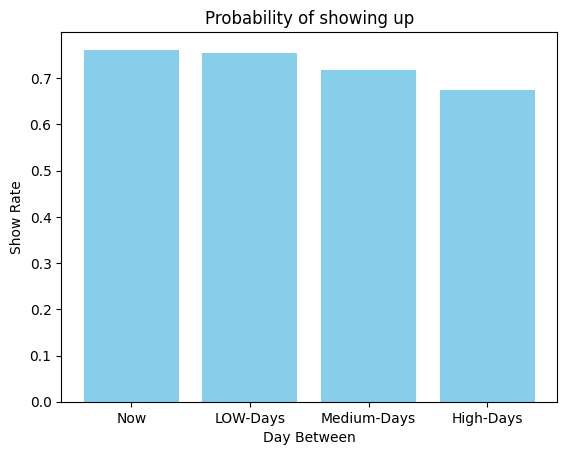

In [40]:
locations = [1, 2, 3, 4]
heights = DB
labels=["Now", "LOW-Days", "Medium-Days", "High-Days"]
chartTitle = 'Probability of showing up'
chartXlabel = 'Day Between'
chartYlabel = 'Show Rate'

draw_plot(locations, heights, labels, chartTitle, chartXlabel, chartYlabel);

The plot reveals that appointments scheduled either very close to or far from the appointment day ('Now' and 'High-Days') exhibit slightly lower show rates compared to those scheduled at moderate intervals ('LOW-Days' and 'Medium-Days'). This suggests that too short notice may not give patients adequate preparation time, whereas very long intervals might lead to forgetfulness or changes in circumstances.


Following the analysis of show rates, this pie chart provides a proportionate representation of how appointments are distributed across the 'Day Between' categories. This visualization helps in understanding which scheduling intervals are most common among the appointments.

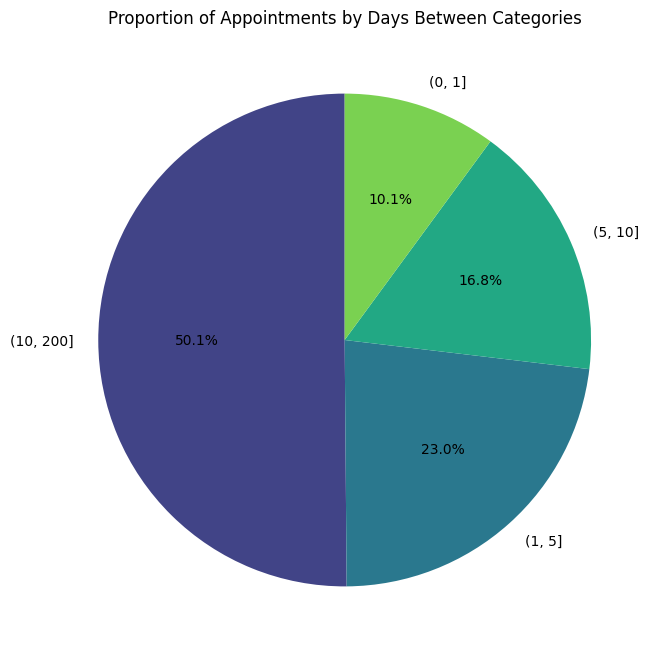

In [44]:
plt.figure(figsize=(8, 8))
df['DayBetween'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', n_colors=4))
plt.title('Proportion of Appointments by Days Between Categories')
plt.ylabel('')
plt.show();

The pie chart indicates that the majority of appointments are scheduled with a 'High-Days' interval (10 to 200 days before the appointment), comprising over half of all appointments. In contrast, very short-term scheduling ('Now') is much less common. This distribution provides context to the previous analysis, as it highlights the scheduling habits and preferences of the patient population.


when the time between the ScheduledDay and AppointmentDay get biger the less likely to show up

### Research Question 2 relationship between health conditions and patient no-shows

In [32]:
hypertension_no_show = df.groupby('Hypertension')['Show'].mean()
diabetes_no_show = df.groupby('Diabetes')['Show'].mean()
alcoholism_no_show = df.groupby('Alcoholism')['Show'].mean()

print("No-show rates for Hypertension:\n\n", hypertension_no_show)
print("No-show rates for Diabetes:\n\n", diabetes_no_show)
print("No-show rates for Alcoholism:\n\n", alcoholism_no_show)

No-show rates for Hypertension:

 Hypertension
0    0.790963
1    0.826980
Name: Show, dtype: float64
No-show rates for Diabetes:

 Diabetes
0    0.796372
1    0.819967
Name: Show, dtype: float64
No-show rates for Alcoholism:

 Alcoholism
0    0.798054
1    0.798512
Name: Show, dtype: float64


i assume that disease equal Hypertension, Diabetes, Alcoholism

In [33]:
df['Disease'] = df['Hypertension'] + df['Alcoholism'] + df['Diabetes']

In [34]:
df_disease = df.groupby('Disease').mean(numeric_only=True)['Show']
df_disease

Disease
0    0.790909
1    0.822034
2    0.822963
3    0.820312
Name: Show, dtype: float64

To further understand the impact of multiple health conditions on patient attendance, this bar chart visualizes the show rates categorized by the number of diseases a patient has. Each category (from 0 to 3 diseases) represents a cumulative condition count including hypertension, diabetes, and alcoholism. This analysis seeks to determine whether patients with more health issues are more or less likely to miss their appointments.

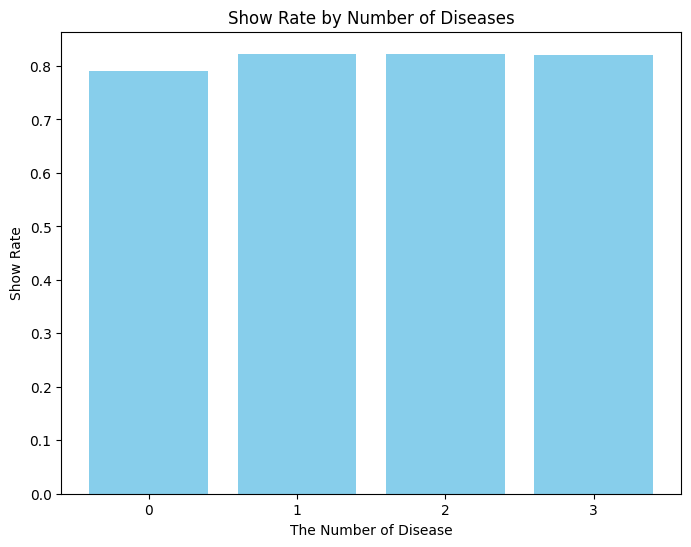

In [35]:
locations = [1, 2, 3, 4]
heights = df_disease
labels = [0, 1, 2, 3]
chartXlabel = 'The Number of Disease'
chartYlabel = 'Show Rate'
chartTitle = 'Show Rate by Number of Diseases'
plt.figure(figsize=(8, 6))

draw_plot(locations, heights, labels, chartTitle, chartXlabel, chartYlabel);

The bar chart indicates that as the number of diseases increases, there is a slight trend towards higher show rates. This suggests that patients with more health issues may prioritize their medical appointments more than those with fewer or no health conditions.

### Trend Analysis of No-Show Probability Based on Disease Count

Following the bar chart, this line graph delves deeper into the probability of no-shows across different disease counts. It aims to highlight any trends or shifts in patient behavior as the number of health conditions changes.

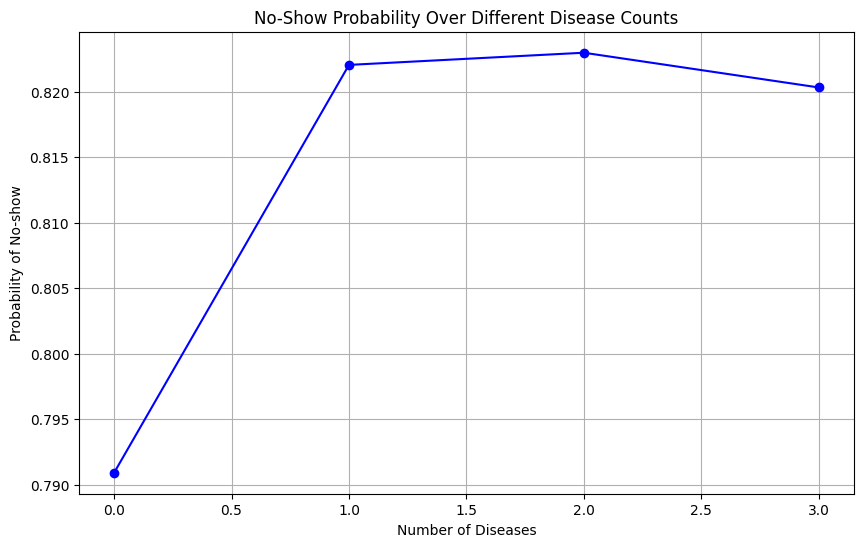

In [46]:
plt.figure(figsize=(10, 6));
plt.plot(df_disease.index, df_disease.values, marker='o', linestyle='-', color='b');
plt.title('No-Show Probability Over Different Disease Counts');
plt.xlabel('Number of Diseases');
plt.ylabel('Probability of No-show');
plt.grid(True);
plt.show();

The line graph further confirms the findings from the bar chart, showing a gradual increase in the probability of attending as the number of diseases increases. This trend underscores the potential impact of more severe health conditions on patient commitment to follow through with scheduled medical visits.


<a id='conclusions'></a>
## Conclusions

This analysis examined how multiple health conditions hypertension, diabetes, and alcoholism and the time between scheduling and appointment dates influence no-show rates at medical appointments. Findings indicate that patients with more health conditions are more likely to attend their appointments, suggesting greater healthcare engagement due to their health needs, while shorter intervals between scheduling and appointments correlate with lower no-show rates, likely due to reduced opportunities for changes in patients availability or forgetfulness.

### Limitation

However, this study has limitations that must be considered when interpreting the results. One significant limitation is the lack of data on external factors such as transportation availability, weather conditions, and socio-economic status, which can all significantly impact a patient’s ability to attend a scheduled appointment.

## Submitting your Project 

In [73]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 392162 bytes to Investigate_a_Dataset.html
